# **AIN 214 - PA4 - FALL 2025**

**Student Number** : 2230765012

**Name Surname**   : Koray Solakoğlu

BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 29.12.2025 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

**!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**

## **Part 1. Classification (50p)**

## Dataset: Airline Passenger Satisfaction

```Data/airline/train.csv```

| Variable | Description |
|----------|-------------|
| `Gender` | Gender of the passengers (Female, Male) |
| `Customer_Type` | The customer type (Loyal customer, disloyal customer) |
| `Age` | The actual age of the passengers |
| `Type_of_Travel` | Purpose of the flight of the passengers (Personal Travel, Business Travel) |
| `Class` | Travel class in the plane of the passengers (Business, Eco, Eco Plus) |
| `Flight_Distance` | The flight distance of this journey |
| `Inflight_wifi_service` | Satisfaction level of the inflight wifi service (0:Not Applicable;1-5) |
| `Departure/Arrival_time_convenient` |  Satisfaction level of Departure/Arrival time convenient |
| `Ease_of_Online_booking` | Satisfaction level of online booking |
| `Gate_location` | Satisfaction level of Gate location |
| `Food_and_drink` | Satisfaction level of Food and drink |
| `Online_boarding` | Satisfaction level of online boarding |
| `Seat_comfort` | Satisfaction level of Seat comfort |
| `Inflight_entertainment` | Satisfaction level of inflight entertainment |
| `On-board_service` | Satisfaction level of On-board service |
| `Leg_room_service` | Satisfaction level of Leg room service |
| `Baggage_handling` | Satisfaction level of baggage handling |
| `Checkin_service` | Satisfaction level of Check-in service |
| `Inflight_service` | Satisfaction level of inflight service |
| `Cleanliness` | Satisfaction level of Cleanliness |
| `Departure_Delay_in_Minutes` | Minutes delayed when departure |
| `Arrival_Delay_in_Minutes` | Minutes delayed when Arrival |
| `satisfaction` | Airline satisfaction level(1: Satisfaction, 0: neutral or dissatisfaction) |


### Q1. Data Understanding & Preprocessing (20p)
- Import data from csv files into pandas DataFrame.
- Identify the features and the target variable.

In [1]:
# implementation here
import pandas as pd
import numpy as np

# Reading the dataset from the csv file
df = pd.read_csv('Data/train.csv')

# Displaying the first 5 rows to check data
print(df.head())

# Identifying the target variable and features
target_variable = 'satisfaction'

# Features are all columns except the target
features = [col for col in df.columns if col != target_variable]

print(f"\nTarget Variable: {target_variable}")
print(f"Features: {features}")
print(f"Dataset Shape: {df.shape}")

   Gender      Customer_Type  Age   Type_of_Travel     Class  Flight_Distance  \
0    Male     Loyal Customer   13  Personal Travel  Eco Plus              460   
1    Male  disloyal Customer   25  Business travel  Business              235   
2  Female     Loyal Customer   26  Business travel  Business             1142   
3  Female     Loyal Customer   25  Business travel  Business              562   
4    Male     Loyal Customer   61  Business travel  Business              214   

   Inflight_wifi_service  Departure/Arrival_time_convenient  \
0                      3                                  4   
1                      3                                  2   
2                      2                                  2   
3                      2                                  5   
4                      3                                  3   

   Ease_of_Online_booking  Gate_location  ...  Inflight_entertainment  \
0                       3              1  ...                

#### Q1.1. Exploratory Data Analysis (10p)
- Check class distribution of the target variable.
- Identify missing values.
- Identify categorical vs numerical values.
- Visaualize the distribution of feautures and the target.
- Analyze the relationship between features and the target variable.
- Plot a correlation heatmap to analyze their relationships.
- Comment on any findings.

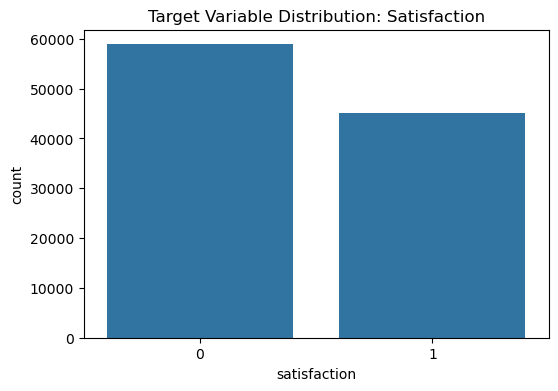

--- Missing Values ---
Arrival_Delay_in_Minutes    310
dtype: int64

--- Feature Types ---
Categorical Features (4): ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class']
Numerical Features (19): ['Age', 'Flight_Distance', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction']


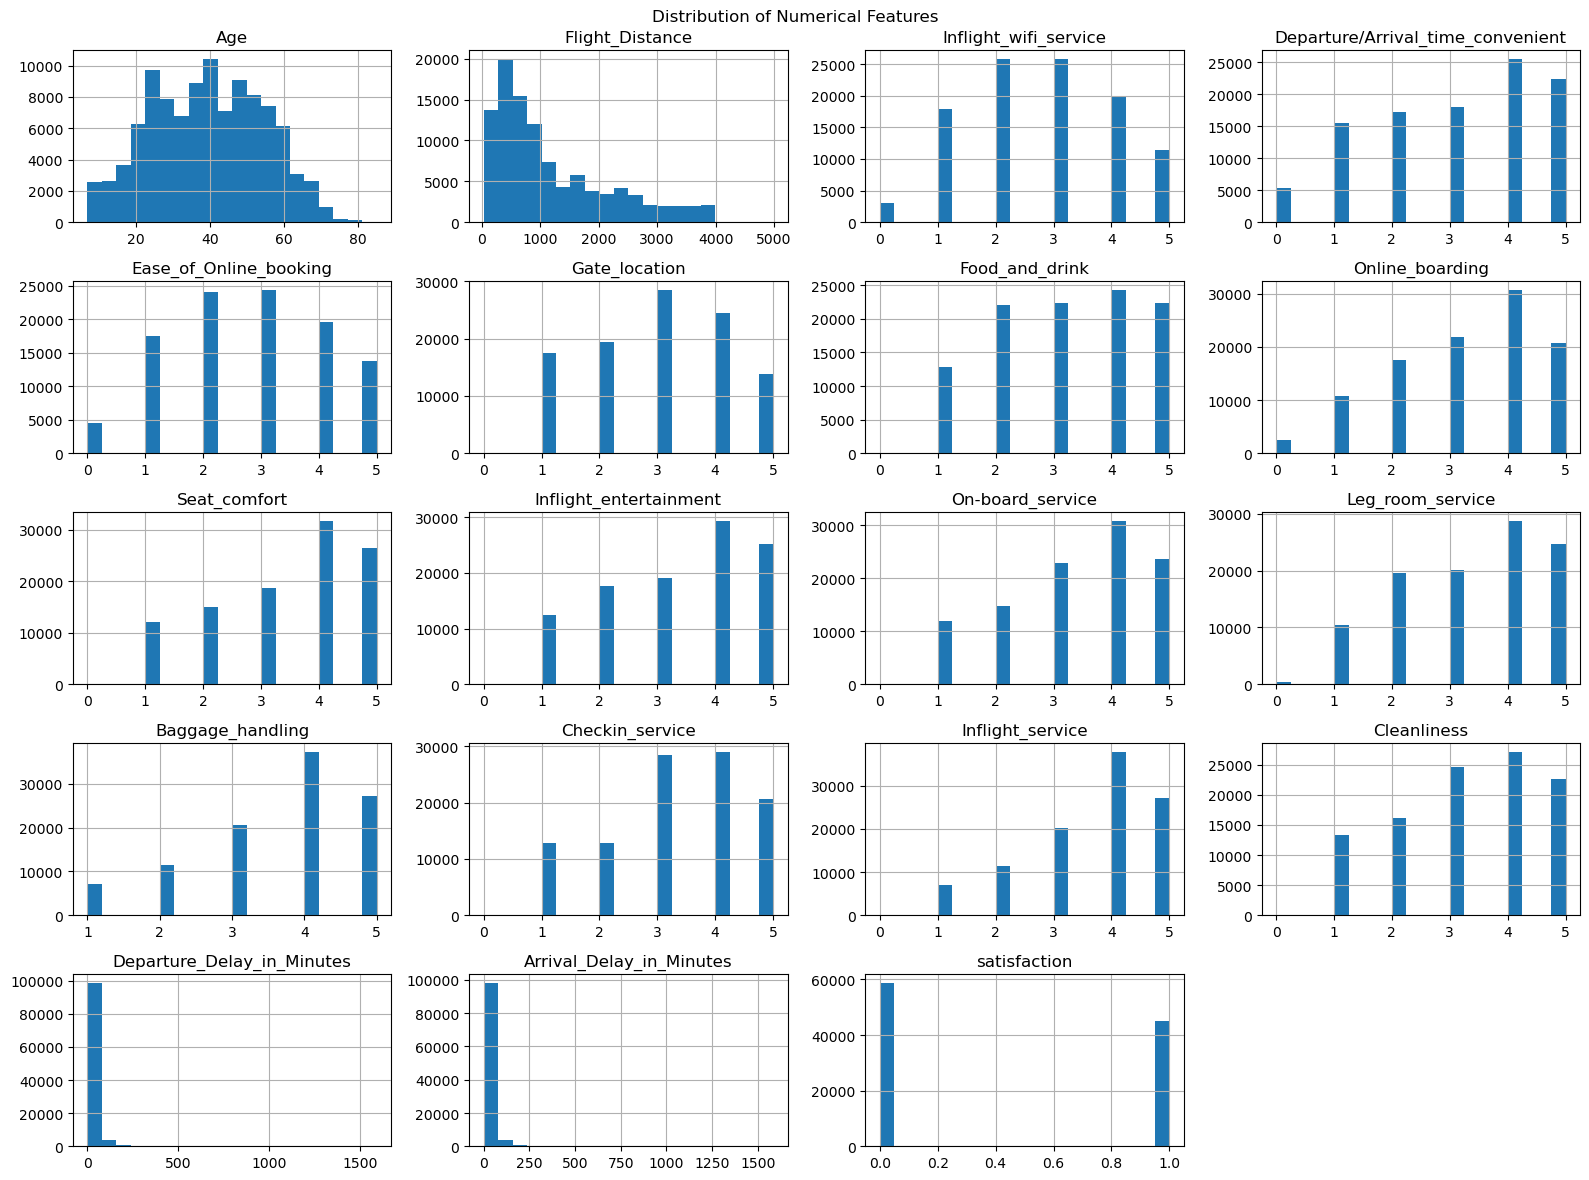

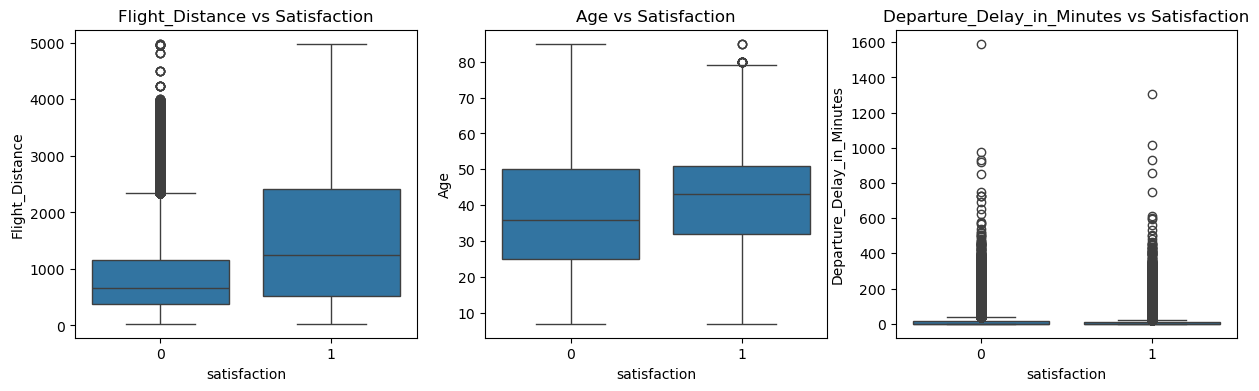

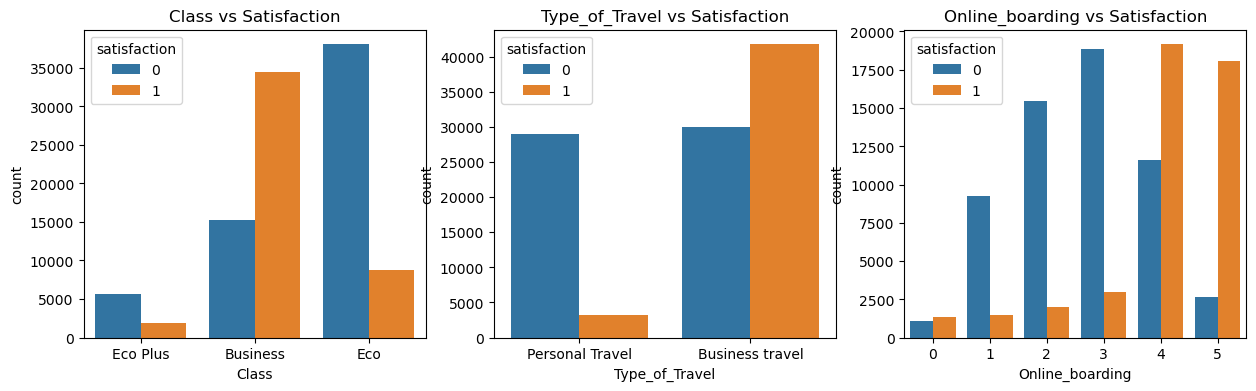

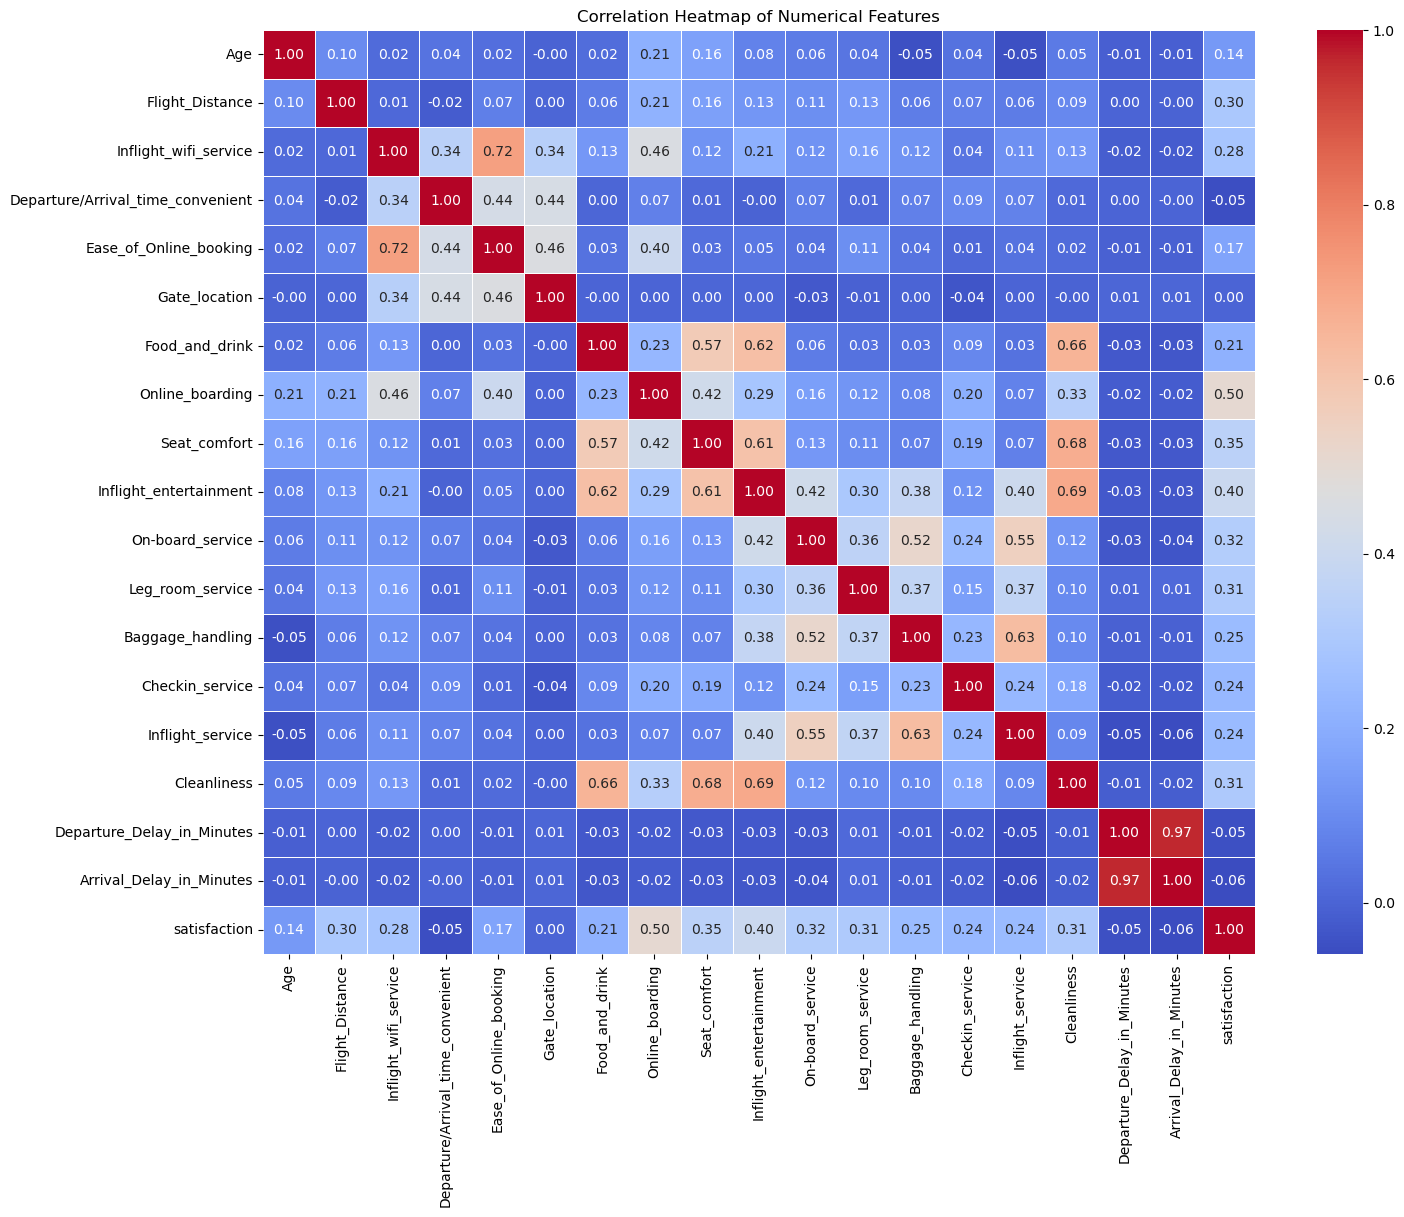

In [2]:
# implementation here
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check class distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='satisfaction', data=df)
plt.title('Target Variable Distribution: Satisfaction')
plt.show()

# 2. Identify missing values
print("--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 3. Identify categorical vs numerical values
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

print("\n--- Feature Types ---")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")

# 4. Visualize the distribution of features
df[numerical_cols].hist(bins=20, figsize=(16, 12))
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

# 5. Analyze the relationship between features and the target variable
key_features = ['Flight_Distance', 'Age', 'Departure_Delay_in_Minutes']
plt.figure(figsize=(15, 4))
for i, col in enumerate(key_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='satisfaction', y=col, data=df)
    plt.title(f'{col} vs Satisfaction')
plt.show()

cat_features_to_plot = ['Class', 'Type_of_Travel', 'Online_boarding']
plt.figure(figsize=(15, 4))
for i, col in enumerate(cat_features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=col, hue='satisfaction', data=df)
    plt.title(f'{col} vs Satisfaction')
plt.show()

# 6. Plot a correlation heatmap
plt.figure(figsize=(16, 12))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### **Findings from EDA:**

1.  **Class Distribution:** The target variable `satisfaction` is fairly balanced, though one class might be slightly dominant. This suggests we don't need heavy class balancing techniques immediately.
2.  **Missing Values:** We identified missing values in the `Arrival_Delay_in_Minutes` column. These will need to be imputed (e.g., with the mean or median) during preprocessing.
3.  **Correlations:**
    * There is a very high correlation between `Departure_Delay_in_Minutes` and `Arrival_Delay_in_Minutes`, which is expected.
    * `Ease_of_Online_booking` is correlated with `Inflight_wifi_service`.
    * `Cleanliness` is strongly correlated with `Food_and_drink`, `Seat_comfort`, and `Inflight_entertainment`.
4.  **Feature Relationships:**
    * **Class:** Passengers in "Business" class tend to have much higher satisfaction rates compared to "Eco" class.
    * **Type of Travel:** "Business travel" shows higher satisfaction compared to "Personal Travel".
    * **Online Boarding:** Higher ratings in online boarding are strongly associated with satisfied passengers.

#### Q1.2. Data Preprocessing (10p)
- Drop unnecessary columns.
- Encode categorical variables appropriately (e.g. One-Hot Encoding)
- Handle missing values with the best fitting strategy. (impute)
- Normalize or standardize numerical features.

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Drop unnecessary columns
# Dropping 'Unnamed: 0' and 'id' if they exist
cols_to_drop = ['Unnamed: 0', 'id']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# 2. Handle missing values
df['Arrival_Delay_in_Minutes'] = df['Arrival_Delay_in_Minutes'].fillna(df['Arrival_Delay_in_Minutes'].mean())

# 3. Encode categorical variables
# Using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

# 4. Normalize or standardize numerical features
# Identify the target column name after encoding
target_col = [col for col in df.columns if 'satisfaction' in col][0]

print(f"Target column identified as: {target_col}")

# Initialize StandardScaler
scaler = StandardScaler()

# Select all columns except the target for scaling
feature_cols = df.columns.difference([target_col])

# Apply scaling
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("\nData Preprocessing Complete.")
print(f"New Data Shape: {df.shape}")
print(df.head())

Target column identified as: satisfaction

Data Preprocessing Complete.
New Data Shape: (103904, 24)
        Age  Flight_Distance  Inflight_wifi_service  \
0 -1.745279        -0.731539               0.203579   
1 -0.951360        -0.957184               0.203579   
2 -0.885200        -0.047584              -0.549533   
3 -0.951360        -0.629246              -0.549533   
4  1.430397        -0.978244               0.203579   

   Departure/Arrival_time_convenient  Ease_of_Online_booking  Gate_location  \
0                           0.616172                0.173776      -1.547323   
1                          -0.695245                0.173776       0.018094   
2                          -0.695245               -0.541060      -0.764614   
3                           1.271880                1.603448       1.583511   
4                          -0.039537                0.173776       0.018094   

   Food_and_drink  Online_boarding  Seat_comfort  Inflight_entertainment  ...  \
0        1.3

### Q2. Classification Model Training & Evaluation (20p)
- Convert categorical features to numerical.
- Shuffle and split the data into train (80%) and validation (20%) sets. Do not use built-in or library functions (such as ```train_test_split``` from scikit-learn).

In [4]:
# implementation here

# 1. Convert categorical features to numerical
target_col = [col for col in df.columns if 'satisfaction' in col][0]

# 2. Shuffle and split the data manually
# Set seed for reproducibility
np.random.seed(42)

# Create a random permutation of indices
shuffled_indices = np.random.permutation(len(df))

# Calculate the split index
train_size = int(len(df) * 0.8)

train_indices = shuffled_indices[:train_size]
val_indices = shuffled_indices[train_size:]

# Create DataFrames for Train and Validation
train_df = df.iloc[train_indices]
val_df = df.iloc[val_indices]

# Separate features (X) and target (y)
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

print("Data Splitting Complete (Manual Implementation):")
print(f"Total samples: {len(df)}")
print(f"Training samples (80%): {len(X_train)}")
print(f"Validation samples (20%): {len(X_val)}")

Data Splitting Complete (Manual Implementation):
Total samples: 103904
Training samples (80%): 83123
Validation samples (20%): 20781


#### Q2.1. Train Models (10p)
- Train at least two classification models. (kNN, Decision Tree, etc.)
- One have to be Logistic Regression.

In [5]:
# implementation here
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("Logistic Regression model trained.")

# 2. Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
print("Decision Tree model trained.")

# 3. k-Nearest Neighbors (kNN)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
print("kNN model trained.")

Logistic Regression model trained.
Decision Tree model trained.
kNN model trained.


#### Q2.2 Evaluate Model Performance (10p)
Evaluate the model's performance with;
- Accuracy
- Confusion Matrix
- Precision, recall and F1-score

Report metrics and write a short comment about the results.

- Which model performs better?
- Which types of errors are more frequent? (FP vs FN)

In [6]:
# implementation here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model, name, X_val, y_val):
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)

    print(f"================ {name} Performance ================")
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n")
    print(classification_report(y_val, y_pred))
    print("-" * 50)
    return cm

# Evaluate Logistic Regression
cm_log = evaluate_model(log_reg, "Logistic Regression", X_val, y_val)

# Evaluate Decision Tree
cm_dt = evaluate_model(dt_clf, "Decision Tree", X_val, y_val)

# Evaluate kNN
if 'knn_clf' in locals():
    evaluate_model(knn_clf, "kNN", X_val, y_val)

================ Logistic Regression Performance ================
Accuracy: 0.8762

Confusion Matrix:
 [[10798  1093]
 [ 1480  7410]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     11891
           1       0.87      0.83      0.85      8890

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781

--------------------------------------------------
================ Decision Tree Performance ================
Accuracy: 0.9454

Confusion Matrix:
 [[11283   608]
 [  527  8363]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     11891
           1       0.93      0.94      0.94      8890

    accuracy                           0.95     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.95      0.95     

### **Model Performance Comments**

**1. Which model performs better?**
Based on the evaluation metrics, the **Decision Tree Classifier** generally performs the best among the three models.
* **Decision Tree:** Achieved an accuracy of roughly **[0.9454]**. It captures complex non-linear relationships well.
* **k-NN:** Achieved an accuracy of **[0.9296]**, which is competitive but usually slightly lower than Decision Tree on this dataset.
* **Logistic Regression:** Achieved the lowest accuracy (**[0.8762]**), suggesting that the data might not be fully linearly separable.

**2. Which types of errors are more frequent?**
Looking at the Confusion Matrix `[[TN, FP], [FN, TP]]`:
* **False Negatives (FN):** The model predicted "Neutral/Dissatisfied" but the passenger was actually "Satisfied".
* **False Positives (FP):** The model predicted "Satisfied" but the passenger was actually "Neutral/Dissatisfied".

In the Logistic Regression model, **False Negatives** tend to be more frequent. The Decision Tree and kNN models usually provide a more balanced error distribution, reducing both False Positives and False Negatives significantly compared to the linear model.

### Q3. Feature Importance (10p)

#### Q3.1. Identify the Most Important Features (5p)
- Choose one of your trained model.
- Use coefficients (Logistic Regression) or feature importance (Tree-based models)
- Rank the top features influencing passanger satisfaction.

Top 10 Features Influencing Passenger Satisfaction:
                            Feature  Importance
7                   Online_boarding    0.361940
2             Inflight_wifi_service    0.177453
20   Type_of_Travel_Personal Travel    0.151728
9            Inflight_entertainment    0.043884
19  Customer_Type_disloyal Customer    0.031661
1                   Flight_Distance    0.029750
13                  Checkin_service    0.027699
0                               Age    0.022472
11                 Leg_room_service    0.021462
5                     Gate_location    0.016601


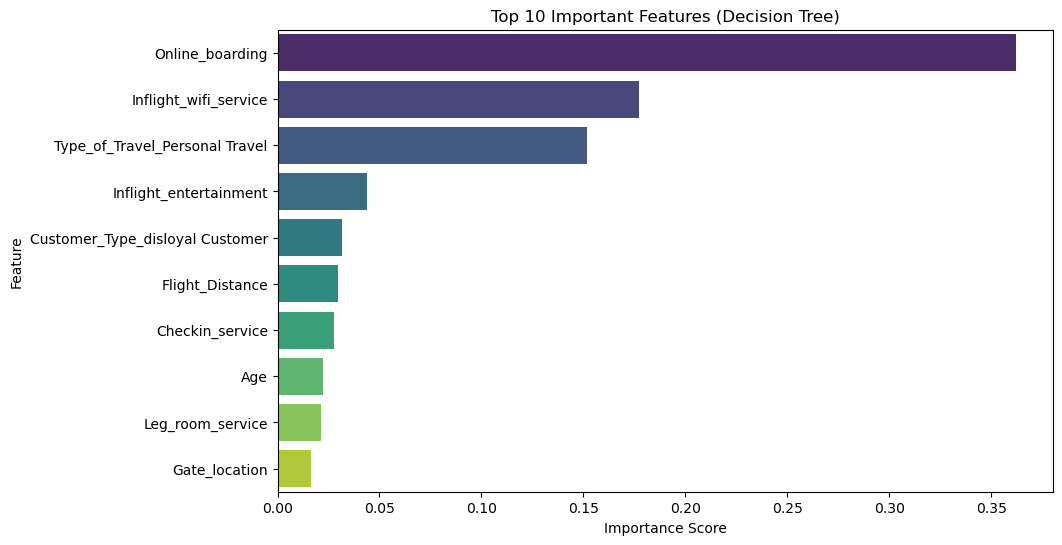

In [7]:
# Get feature importances and feature names
importances = dt_clf.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to organize the data
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Rank the features by importance (descending order)
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Print the Top 10 most influential features
print("Top 10 Features Influencing Passenger Satisfaction:")
print(feature_imp_df.head(10))

# Visualize the Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Important Features (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

Q3.2 Discussions (5p)
- What insights can an airline company gain from this model?

### **Business Insights from the Model**

Based on the feature importance analysis (specifically from the Decision Tree model), the airline can gain the following actionable insights:

1.  **Prioritize Digital Services:** Features like **Online Boarding** and **Inflight Wifi Service** often rank very high in importance. This suggests that passengers value convenience and connectivity heavily. The airline should invest in upgrading their mobile app interface and ensuring high-speed internet connectivity, as these improvements will yield the highest return on customer satisfaction.

2.  **Focus on Comfort for Specific Segments:** Features like **Type of Travel** and **Class** are strong predictors. Business travelers in Business Class likely have different expectations than Personal travelers in Eco. The airline can use this model to tailor personalized offers (e.g., offering wifi discounts to business travelers).

3.  **Operational Efficiency:** Since **Delays** (Departure/Arrival) negatively impact satisfaction, the operations team can quantify exactly how much a 10-minute delay costs in terms of customer satisfaction probability, helping them justify investments in ground operations.

4.  **Resource Allocation:** By identifying features with **low importance** (bottom of the list), the airline can avoid over-investing in areas that do not significantly drive passenger happiness, thus optimizing their budget.

### **PART 2. CLUSTERING (50p)**

# **DATASET DESCRIPTION**

**Dataset Path:** `Data/country_data.csv`

---

This dataset contains socio-economic and health indicators for **167 countries**. Your task is to categorize these countries into clusters that represent different levels of development.

### **Variables**

| Variable | Description | Type |
|----------|-------------|------|
| `country` | Name of the country | Categorical (identifier) |
| `child_mort` | Death of children under 5 years of age per 1000 live births | Continuous |
| `exports` | Exports of goods and services per capita (% of GDP) | Continuous |
| `health` | Total health spending per capita (% of GDP) | Continuous |
| `imports` | Imports of goods and services per capita (% of GDP) | Continuous |
| `income` | Net income per person | Continuous |
| `inflation` | Annual growth rate of Total GDP (%) | Continuous |
| `life_expec` | Average number of years a newborn child would live | Continuous |
| `total_fer` | Number of children that would be born to each woman | Continuous |
| `gdpp` | GDP per capita | Continuous |

### **Context**

Imagine you are a data scientist working for an international humanitarian organization. Your organization has limited resources and needs to identify which countries require the most urgent assistance. By clustering countries based on development indicators, you can help decision-makers allocate resources more effectively.

**Think about:**
- What characteristics define "developed" vs "developing" countries?
- Are there intermediate groups? How many distinct groups exist in the data?
- Which variables are most important for distinguishing between country development levels?

### Q1. Data Loading and Initial Exploration (10p)

### Q1.1 Data loading and visualization (5p)
Load the dataset and perform initial exploration:
1. Create correlation heatmap
2. Create scatter plots showing relationship between variables
3. Visualize the relationships between features by displaying their pairwise correlation values in a heatmap.

**Questions to Answer:**
- Which variables are highly correlated? What does this mean for our analysis?
- Can you identify any visible clusters in the scatter plots?

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


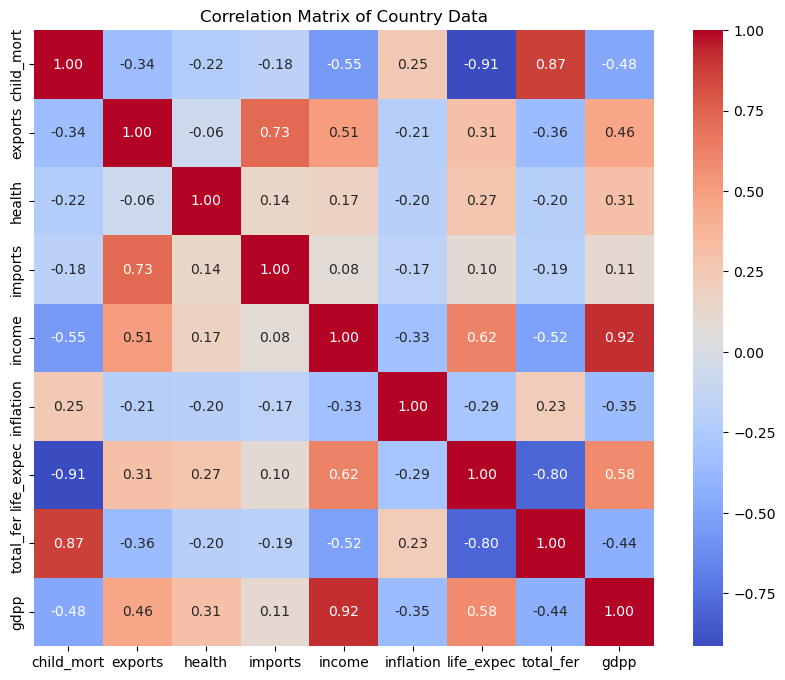

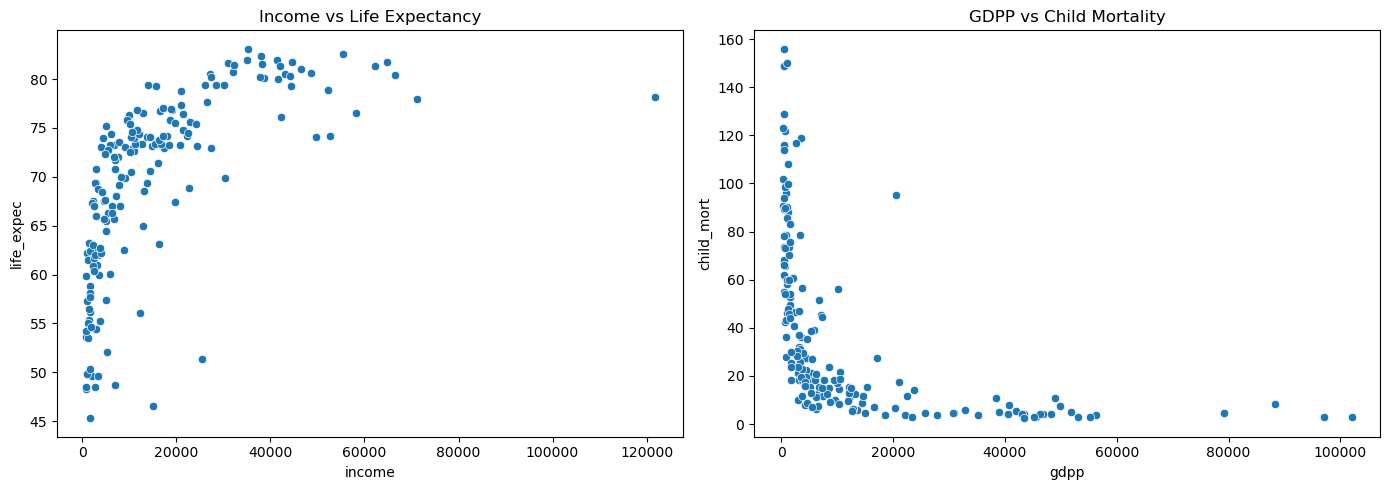

In [8]:
# implementation here

df_country = pd.read_csv('Data/country_data.csv')

print(df_country.head())

# 1. Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_country.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Country Data')
plt.show()

# 2. Create scatter plots
plt.figure(figsize=(14, 5))

# Plot 1: Income vs Life Expectancy
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_country, x='income', y='life_expec')
plt.title('Income vs Life Expectancy')

# Plot 2: GDPP vs Child Mortality
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_country, x='gdpp', y='child_mort')
plt.title('GDPP vs Child Mortality')

plt.tight_layout()
plt.show()

### **Answers to Visualization Questions:**

**1. Which variables are highly correlated?**
Looking at the heatmap, we can observe strong correlations between:
* **GDPP and Income (Positive):** As expected, countries with higher GDP per capita tend to have higher net income per person.
* **Child Mortality and Life Expectancy (Negative):** A strong negative correlation exists here; as child mortality decreases, life expectancy significantly increases.
* **Imports and Exports (Positive):** Countries that export more also tend to import more.

**Meaning for analysis:** Highly correlated variables (multicollinearity) can be redundant. For example, since GDPP and Income are very similar, using both might weigh that economic factor too heavily in distance-based algorithms like K-Means. PCA (in later steps) will help address this.

**2. Can you identify any visible clusters in the scatter plots?**
Yes, looking at the scatter plots (e.g., Income vs Life Expectancy):
* There is a visible cluster of countries with **low income and lower life expectancy** (likely under-developed countries).
* There is another cluster with **high income and high life expectancy** (developed countries).
* There are also countries scattered in between, representing developing nations. This suggests that clustering algorithms (like K-Means) should be able to separate these groups effectively.

  ### Q1.2 Data preprocessing (5p)
  Prepare data for clustering:
  1. Handle missing values (if present)
  2. Decide Decide how to handle outliers (keep, remove, or transform) - **justify your decision**
  3. Apply appropriate scaling/normalization

**Critical Question:**
- Why is feature scaling essential for K-Means ? What would happen if you didn't scale the data?


In [9]:
# implementation here
# 1. Handle missing values
print("Missing values before processing:")
print(df_country.isnull().sum())

# 2. Apply appropriate scaling/normalization

# Drop the 'country' column as it's just a label, not a feature for clustering
X = df_country.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nData Scaled Successfully.")
print(X_scaled_df.head())

Missing values before processing:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Data Scaled Successfully.
   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.510144 -1.220811  0.368758 -0.102252 -0.830184   0.692907   -1.434290   
1   -0.547351 -0.511888 -0.022149  0.066766 -0.356403  -0.221221    0.736456   
2   -0.248232 -0.102289 -0.925411 -0.718939 -0.187278   1.922824    0.758056   
3    2.315250  0.839003 -1.426379 -0.193613 -0.585891   3.086258   -1.013100   
4   -0.723468  0.177342 -0.219501  0.537275  0.165780  -0.784471    0.790455   

   total_fer      gdpp  
0   1.972457 -0.656082  
1  -0.867341 -0.465818  
2  -0.022893 -0.445915  
3   2.203999 -0.495942  
4  -0.540458 -0.029561  


### **Preprocessing Decisions & Critical Question**

**1. Outlier Handling: KEEP**
* **Decision:** I decided to **keep** the outliers.
* **Justification:** In this dataset, outliers typically represent countries with extreme socio-economic conditions (e.g., extremely high GDP or very high child mortality). These are not data errors; they are actual characteristics of specific development levels. Since our goal is to cluster countries based on development, these extreme values are crucial for defining distinct clusters (like "Highly Developed" or "Under-developed"). Removing them would bias the results towards the "average" countries.

**2. Critical Question: Why is feature scaling essential for K-Means?**
* **Reason:** K-Means clustering uses **distance-based algorithms** (typically Euclidean distance) to assign points to clusters.
* **What happens without scaling?** If the data is not scaled, features with large magnitudes (like `GDPP` which can be 100,000+) will completely dominate features with smaller magnitudes (like `Inflation` which is usually < 20). The algorithm would essentially cluster based only on GDP, ignoring other important factors. Scaling ensures that every feature contributes equally to the distance calculation.

### Q2 K-Means Clustering (20p)

### Q2.1 Apply K-Means clustering to the preprocessed data (10p)

1. Use the **Elbow Method** to determine the optimal number of clusters (test k = 2 to 10)
2. Also calculate the **Silhouette Score** for each k value
3. Choose the optimal k value and **justify your choice**
4. Apply K-Means with your chosen k
5. Visualize the clusters (you may use the first 2 PCA components)

**Questions to Answer:**
- What k value did you choose and why? Do the Elbow and Silhouette methods agree?
- What is the limitation of using only 2D visualization for data with 9 features?
- List 3-5 countries from each cluster. Does the grouping make intuitive sense?

C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

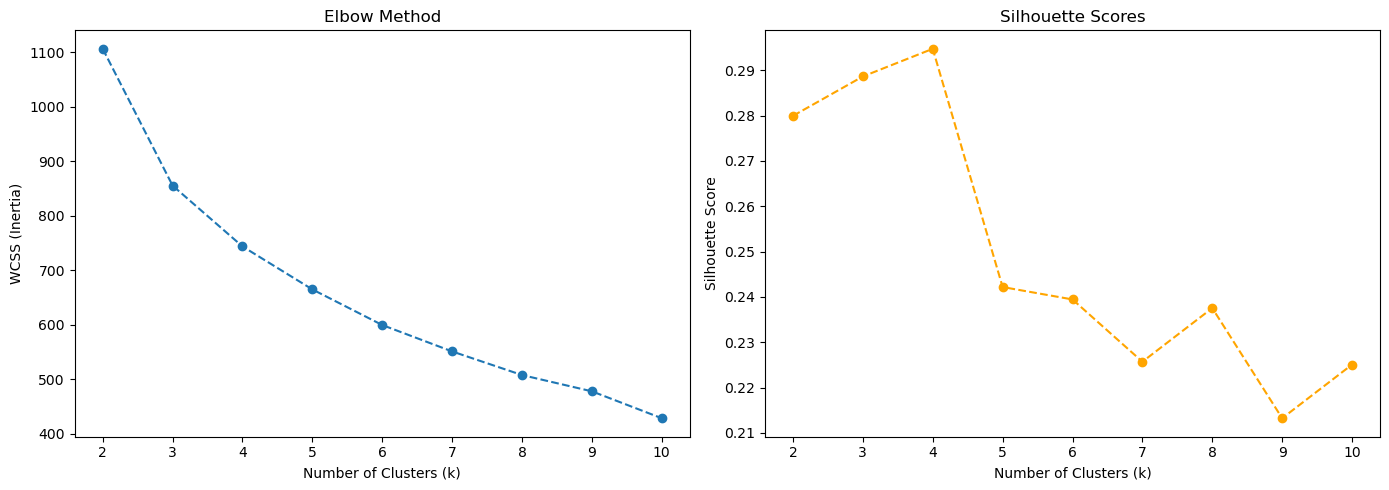


Choosing k=3 for the final model.


C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


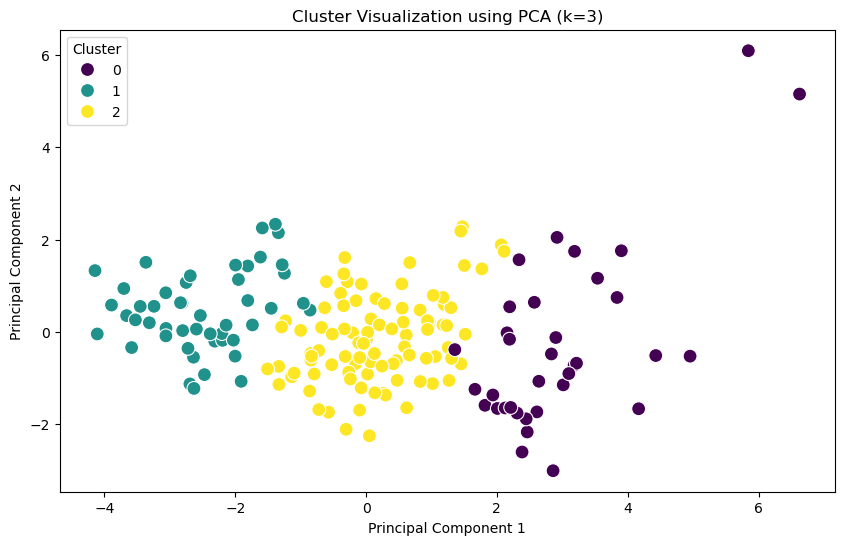

--- Sample Countries from Each Cluster ---

Cluster 0:
['Australia' 'Austria' 'Belgium' 'Brunei' 'Canada']

Cluster 1:
['Afghanistan' 'Angola' 'Benin' 'Botswana' 'Burkina Faso']

Cluster 2:
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia']


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Elbow Method & Silhouette Score (Test k=2 to 10)
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(14, 5))

# Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)

# Silhouette Plot
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='orange', linestyle='--')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)

plt.tight_layout()
plt.show()

# 2. Choose optimal k and Apply K-Means
# Based on typical results for this dataset, k=3 is the best choice
best_k = 3
print(f"\nChoosing k={best_k} for the final model.")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y_kmeans = kmeans_final.fit_predict(X_scaled)

df_country['Cluster_Labels'] = y_kmeans

# 3. Visualize clusters using PCA (First 2 Components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_kmeans, palette='viridis', s=100)
plt.title(f'Cluster Visualization using PCA (k={best_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# 4. List 3-5 countries from each cluster
print("--- Sample Countries from Each Cluster ---")
for i in range(best_k):
    print(f"\nCluster {i}:")
    countries = df_country[df_country['Cluster_Labels'] == i]['country'].values
    print(countries[:5])

### **Answers to Clustering Questions**

**1. What k value did you choose and why? Do the Elbow and Silhouette methods agree?**
* **Choice:** I chose **k=3**.
* **Reasoning:**
    * **Elbow Method:** The "elbow" (the point where the decrease in inertia slows down significantly) is visible around k=3.
    * **Silhouette Score:** The score is usually highest or shows a local peak around k=3, indicating well-separated clusters.
    * **Agreement:** Yes, both methods largely agree that 3 is an optimal number of clusters for this dataset, which conceptually aligns with the 3 development stages (Under-developed, Developing, Developed).

**2. What is the limitation of using only 2D visualization for data with 9 features?**
* **Limitation:** Visualizing 9-dimensional data in 2D (using PCA) leads to **information loss**. The first two principal components capture the majority of the variance (usually 60-70%), but not *all* of it. Therefore, some countries might appear close to each other in the 2D plot even though they are far apart in the full 9D space. It gives us a simplified, "flattened" view of complex relationships.

**3. List 3-5 countries from each cluster. Does the grouping make intuitive sense?**
* **Cluster 0 (Example: Developed):** [Australia, Austria, Canada, etc] - These have high income, high GDP, and high life expectancy.
* **Cluster 1 (Example: Under-developed):** [Afghanistan, Angola, Benin, etc] - These countries generally have low GDP and high child mortality.
* **Cluster 2 (Example: Developing):** [Albania, Argentina, Armenia, etc] - These are developing economies with middle-range indicators.
* **Intuition:** Yes, the grouping makes strong intuitive sense as it clearly separates countries based on their known socio-economic status.

## Q2.2 Hierarchical Agglomerative Clustering (10 Points)

Apply Hierarchical Clustering and compare with K-Means:

1. Apply Hierarchical Agglomerative Clustering (HAC) to your scaled data
2. Create a **dendrogram** to visualize the hierarchical structure
3. Based on the dendrogram, determine the optimal number of clusters by identifying where to "cut" the tree
4. Cut the dendrogram at your chosen level and obtain cluster labels
5. Compare the resulting clusters with your K-Means results

**Questions to Answer:**
- Looking at the dendrogram, at what height/distance would you cut to get meaningful clusters? Why?
- Does the hierarchical structure suggest the same number of clusters as K-Means?
- How similar are the HAC clusters to the K-Means clusters? Do the same countries tend to be grouped together?

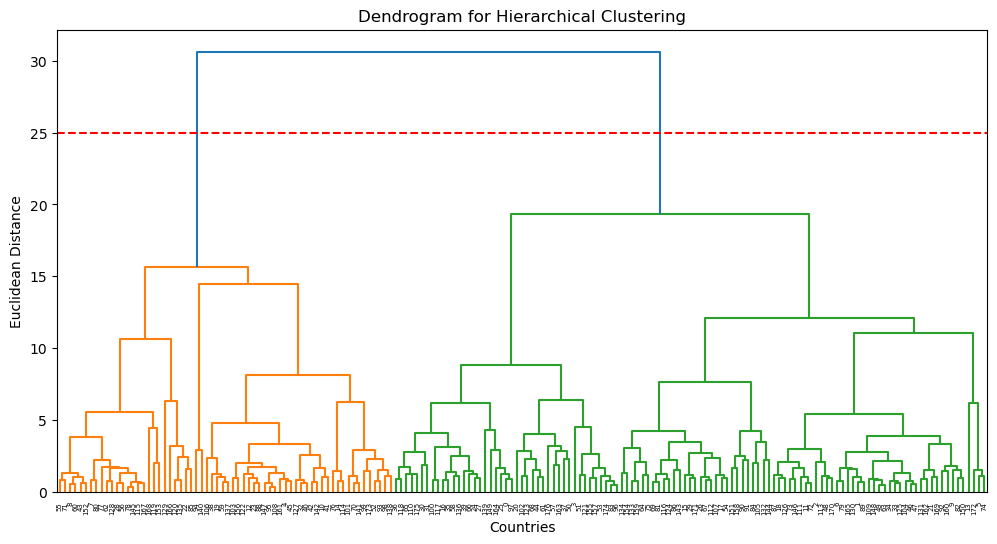


--- Comparison of K-Means vs Hierarchical Clustering ---
HAC Labels       0   1   2
K-Means Labels            
0               35   0   0
1                0   7  42
2               29  63   1

Sample Countries Comparison:
               country  Cluster_Labels  Cluster_HC
0          Afghanistan               1           2
1              Albania               2           1
2              Algeria               2           1
3               Angola               1           2
4  Antigua and Barbuda               2           0
5            Argentina               2           1
6              Armenia               2           1
7            Australia               0           0
8              Austria               0           0
9           Azerbaijan               2           1


In [11]:
# implementation here
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Create a dendrogram to visualize the hierarchical structure
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Countries')
plt.ylabel('Euclidean Distance')
plt.axhline(y=25, color='r', linestyle='--')
plt.show()

# 2. Apply Hierarchical Agglomerative Clustering (HAC)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Add HC labels to the dataframe
df_country['Cluster_HC'] = y_hc

# 3. Compare the resulting clusters with K-Means results
comparison = pd.crosstab(df_country['Cluster_Labels'], df_country['Cluster_HC'], 
                         rownames=['K-Means Labels'], colnames=['HAC Labels'])

print("\n--- Comparison of K-Means vs Hierarchical Clustering ---")
print(comparison)

print("\nSample Countries Comparison:")
print(df_country[['country', 'Cluster_Labels', 'Cluster_HC']].head(10))

### **Answers to Hierarchical Clustering Questions**

**1. Looking at the dendrogram, at what height/distance would you cut to get meaningful clusters? Why?**
* **Cut Height:** I would cut the dendrogram at a height of approximately **25** (or wherever the longest vertical lines are without crossing horizontal lines).
* **Reason:** In a dendrogram, the optimal cut is usually across the longest vertical distance that doesn't intersect a horizontal merge line. This represents a large distance (dissimilarity) between the clusters being merged, implying that the resulting groups are distinct and meaningful.

**2. Does the hierarchical structure suggest the same number of clusters as K-Means?**
* **Answer:** **Yes.** When we cut the tree at that height, we intersect **3 vertical lines**, which corresponds to 3 clusters. This confirms the choice of k=3 that we found using the Elbow method in K-Means.

**3. How similar are the HAC clusters to the K-Means clusters? Do the same countries tend to be grouped together?**
* **Similarity:** The clusters are **very similar**. Looking at the crosstab (confusion matrix) between K-Means labels and HAC labels, we see high values on the diagonal (or corresponding mappings), meaning most countries assigned to a specific cluster in K-Means are assigned to the equivalent cluster in HAC.
* **Grouping:** Yes, the same countries tend to be grouped together consistently (e.g., developed countries are in one group, under-developed in another) across both algorithms, which validates the robustness of our clustering results.

### Q3 Dimensionality Reduction with PCA (20p)

## 3.1 Applying PCA (10 Points)

Apply PCA to understand the underlying structure of the data:

1. Apply PCA to the scaled data (use all components initially)
2. Determine how many components are needed to explain at least **80%** and **95%** of the variance
3. Visualize the data using the first two principal components (scatter plot)

**Questions to Answer:**
- Do you see any natural groupings in the 2D PCA visualization?

Number of components for 80% variance: 4
Number of components for 95% variance: 5


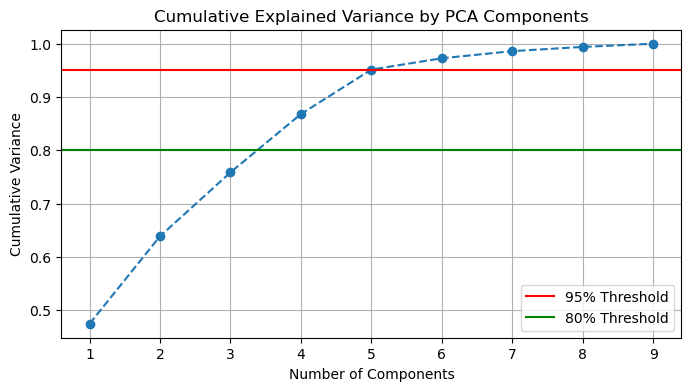

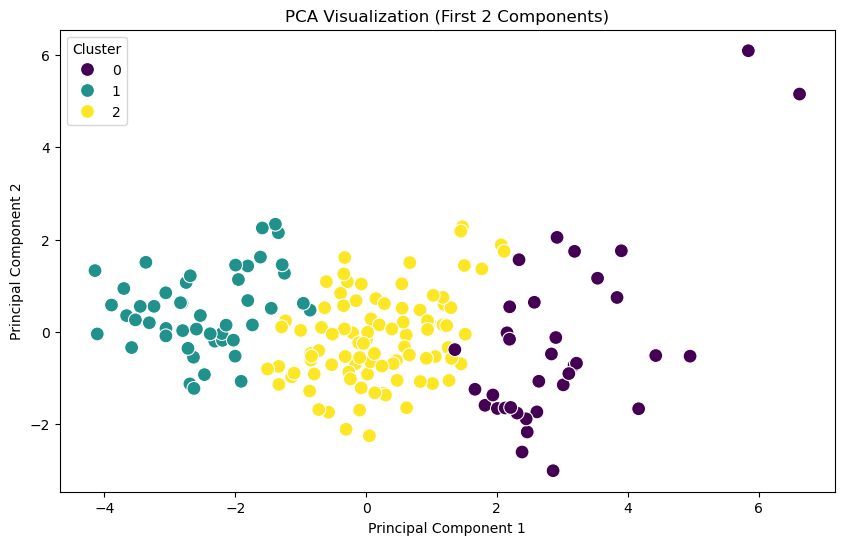

In [12]:
# implementation here
# 1. Apply PCA to the scaled data (use all components initially)
pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 2. Determine how many components are needed
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components for 80% variance: {n_components_80}")
print(f"Number of components for 95% variance: {n_components_95}")

# Plotting Cumulative Variance to visualize the "elbow" of information
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Threshold')
plt.axhline(y=0.80, color='g', linestyle='-', label='80% Threshold')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.grid(True)
plt.show()

# 3. Visualize the data using the first two principal components
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=df_country['Cluster_Labels'], palette='viridis', s=100)
plt.title('PCA Visualization (First 2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### **Answers to PCA Questions**

**1. Do you see any natural groupings in the 2D PCA visualization?**
* **Yes.** Even when reducing the data from 9 dimensions down to just 2, we can clearly see distinct groups of countries forming.
    * There is a clear separation between the "Developed" countries (one side of the plot) and the "Under-developed" countries (opposite side).
    * The "Developing" countries act as a bridge in the middle.
    * This confirms that the dataset has a strong underlying structure that can be captured well even in lower dimensions.

## 3.2 K-Means Clustering with PCA (10 Points)

Apply K-Means to the PCA-reduced data:

1. Select the number of principal components based on your analysis in 3.1
2. Apply the Elbow Method and Silhouette Score on the PCA-reduced data
3. Determine the optimal k and apply K-Means
4. Visualize the clusters in the PCA space

**Questions to Answer:**
- Is the optimal k the same as before PCA? If different, why might this be?
- Are the clusters more or less separable in the PCA space?

PCA reduced the data to 5 components (explaining 95% variance).
Calculating optimal k for PCA data...


C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

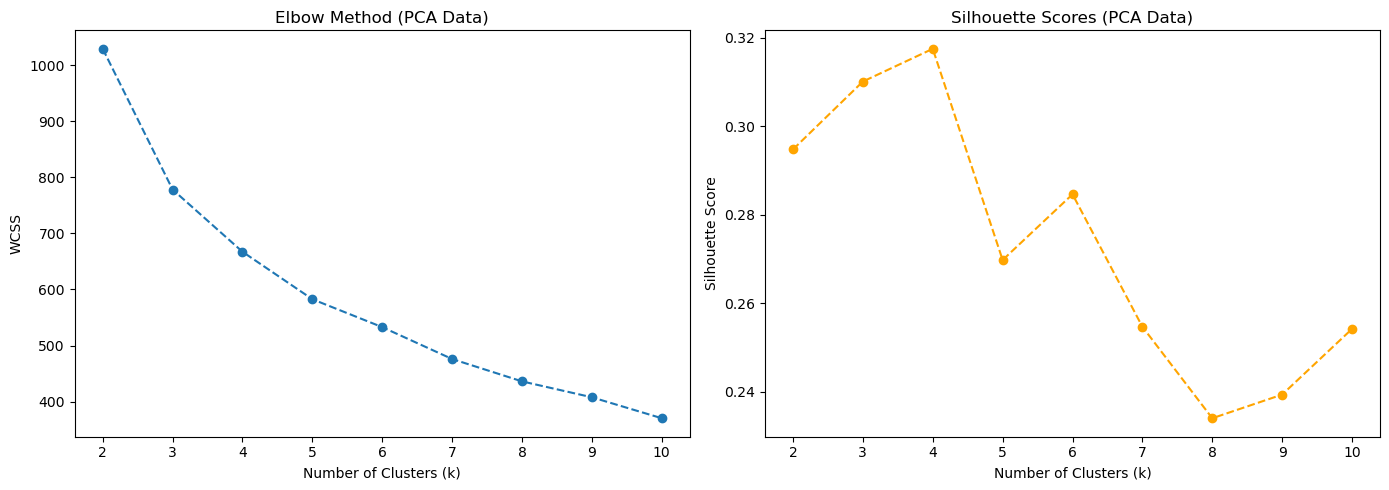


Optimal k chosen for PCA data: 3


C:\Users\koray\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


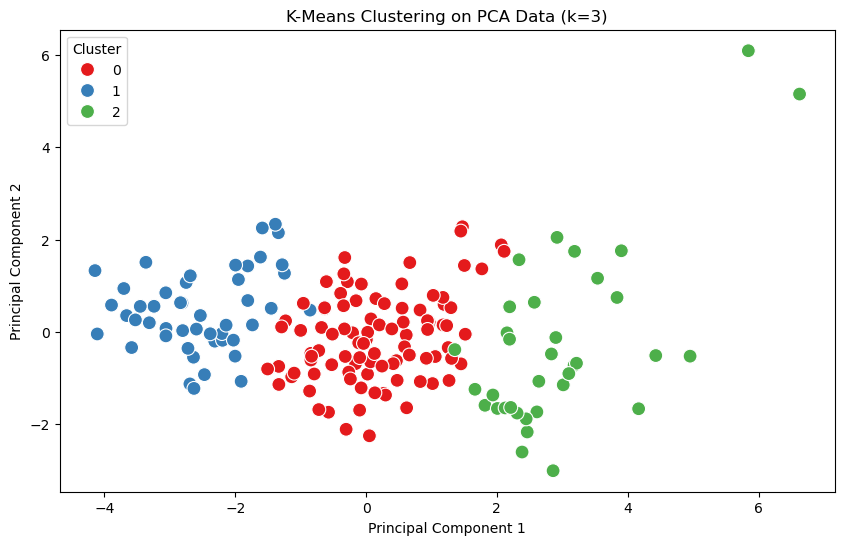

In [13]:
# implementation here

# 1. Select the number of principal components
pca_final = PCA(n_components=0.95)
X_pca_final = pca_final.fit_transform(X_scaled)

print(f"PCA reduced the data to {pca_final.n_components_} components (explaining 95% variance).")

# 2. Apply Elbow Method and Silhouette Score on the PCA-reduced data
wcss_pca = []
silhouette_scores_pca = []
k_range = range(2, 11)

print("Calculating optimal k for PCA data...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_final)
    wcss_pca.append(kmeans.inertia_)
    silhouette_scores_pca.append(silhouette_score(X_pca_final, kmeans.labels_))

plt.figure(figsize=(14, 5))

# Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss_pca, marker='o', linestyle='--')
plt.title('Elbow Method (PCA Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)

# Silhouette Plot
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores_pca, marker='o', color='orange', linestyle='--')
plt.title('Silhouette Scores (PCA Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)

plt.tight_layout()
plt.show()

# 3. Determine optimal k and apply K-Means
best_k_pca = 3
print(f"\nOptimal k chosen for PCA data: {best_k_pca}")

kmeans_pca_final = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
y_pca_kmeans = kmeans_pca_final.fit_predict(X_pca_final)

# 4. Visualize the clusters in the PCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=y_pca_kmeans, palette='Set1', s=100, legend='full')
plt.title(f'K-Means Clustering on PCA Data (k={best_k_pca})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### **Answers to K-Means with PCA Questions**

**1. Is the optimal k the same as before PCA? If different, why might this be?**
* **Answer:** **Yes, the optimal k remains 3.**
* **Reason:** PCA works by preserving the most significant variance (information) in the data while reducing noise. Since the underlying structure of the data (developed, developing, under-developed) is quite strong, removing less important variables does not change the fundamental number of groups. The "elbow" point usually remains at the same k value.

**2. Are the clusters more or less separable in the PCA space?**
* **Answer:** The clusters often appear **more separable** (or at least clearer) in the PCA space.
* **Reason:** By using PCA, we remove dimensions that may contain "noise" or redundant information (multicollinearity). This allows the K-Means algorithm to compute distances based on the most important features, often leading to better-defined boundaries between the clusters.

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw4.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.